# Td-Tp 4 : Réseau neuronal convolutif (CNN)

Nous sommes sur le point de faire un autre exercice de programmation de réseau neuronal ! Cette fois, l'objectif de cet exercice est d'entraîner un réseau neuronal pour la reconnaissance d'images. En raison des avantages des réseaux de neurones convolutifs pour l'information spatiale, l'utilisation de réseaux de neurones convolutifs pour réaliser la reconnaissance d'images est un contenu d'apprentissage très important. De même, l'exécution des tâches de programmation suivantes vous guidera tout au long du processus de création de réseau.

**Quelques exigences supplémentaires :**
1. N'utilisez pas de boucles (for/while) dans votre code à moins que les instructions ne vous l'indiquent explicitement.
2. Utilisez `np.dot(X,Y)` pour calculer le produit scalaire.

**Objectif d'apprentissage :**
Créez un algorithme, comprenant les étapes suivantes :
1. Initialiser les paramètres
2. Implémenter l'opération de convolution (CONV)
3. Implémenter l'opération de pooling (POOL)
4. Combiner les fonctions ci-dessus dans le bon ordre en une seule fonction de modèle principale
<img src="images/CNN.png" style="width:800">

**Remarque** :
Pour chaque fonction de propagation avant, il existe son équivalent correspondant de rétropropagation. Par conséquent, à chaque étape de votre module de propagation avant, vous stockerez certains paramètres dans un cache. Ces paramètres seront utilisés pour calculer les gradients lors de la rétropropagation.

Nous supposons que vous connaissez déjà `numpy` et/ou que vous avez suivi les cours précédents. Commençons !

## Table des matières
- [1 - Packages](#1)
- [2 - Aperçu de l'ensemble des problèmes](#2)
    - [2.1 - Zero-Padding](#2-1)
        - [Exercice 1 - zero_pad](#ex-1)
    - [2.2 - Une seule étape de convolution](#2-2)
        - [Exercice 2 - conv_single_step](#ex-2)
    - [2.3 - Propagation avant](#2-3)
        - [Exercice 3 - conv_forward](#ex-3)
- [3 - Couche de pooling](#3)
    - [3.1 - Propagation avant](#3-1)
        - [Exercice 4 - pool_forward](#ex-4)
- [4 - Rétropropagation dans les CNNs](#4)
    - [4.1 - Rétropropagation dans la couche de convolution](#4.1)
        - [4.1.1 - Calculer dH](#4.1.1)
        - [4.1.2 - Calculer dL](#4.1.2)
        - [4.1.3 - Calculer db](#4.1.3)
            - [Exercice 5 - conv_backward](#ex-5)
    - [4.2 - Rétropropagation dans la couche de pooling](#4.2)
        - [4.2.1 - Max pooling](#4.2.1)
            - [Exercice 6 - create_mask_from_window](#ex-6)
        - [4.2.2 - Average pooling](#4.2.2)
            - [Exercice 7 - distribute_value](#ex-7)
            - [Exercice 8 - pool_backward](#ex-8)
- [5 - Implémentation de la reconnaissance d'images (facultatif)](#5)

<a name='1'></a>
## 1 – Packages

Importons d'abord tous les packages dont vous aurez besoin lors de cette mission.
- [numpy](www.numpy.org) est le package fondamental pour le calcul scientifique avec Python.
- [h5py](http://www.h5py.org) est un package courant permettant d'interagir avec un ensemble de données stocké dans un fichier H5.
- [matplotlib](http://matplotlib.org) est une bibliothèque pour tracer des graphiques en Python.
- `np.random.seed(1)` est utilisé pour maintenir la cohérence de tous les appels de fonctions aléatoires.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

np.random.seed(1)

<a name='2'></a>
## 2 - Réseaux de neurones convolutifs

Dans cette partie, vous allez construire chaque étape de la couche de convolution. Vous commencerez par implémenter deux fonctions d’assistance : une pour le remplissage nul (zero padding) et l’autre pour calculer la fonction de convolution elle-même.

<a name='2-1'></a>
### 2.1 - Zero-padding
Le remplissage nul (zero-padding) ajoute des zéros autour de la bordure d'une image :
<img src="images/PAD.png" style="width:600">
Les principaux avantages du rembourrage sont les suivants :
- Il permet d'utiliser une couche CONV sans nécessairement réduire la hauteur et la largeur des volumes. Ceci est important pour construire des réseaux plus profonds, sinon la hauteur/largeur diminuerait à mesure que vous accédez à des couches plus profondes. Un cas particulier important est la « même » convolution, dans laquelle la hauteur/largeur est exactement préservée après une couche.
- Cela nous aide à conserver davantage d'informations en bordure d'une image. Sans remplissage, très peu de valeurs du calque suivant seraient affectées par les pixels comme bords d'une image.

<a name='ex-1'></a>
### Exercice 1 - Zero-Padding
Implémentez la fonction suivante, qui remplit toutes les images d'un lot d'exemples X avec des zéros. [Utilisez np.pad](https://docs.scipy.org/doc/numpy/reference/generated/numpy.pad.html).
Notez que si vous souhaitez remplir le tableau "a" de forme $(5,5,5,5,5)$ avec `pad = 1` pour les deux côtés de la 2ème dimension, `pad = 3` pour la 4ème dimension et `pad = 0` pour le reste, vous feriez :
```python
a = np.pad(a, ((0,0), (1,1), (0,0), (3,3), (0,0)), 'constant', constant_values = (..,..))
```
<img src="images/padding_2.png" style="width:600">

In [2]:
## zero_pad

def zero_pad(X, pad):
    """
    Remplissez avec des zéros toutes les images de l'ensemble de données X. 
    Le remplissage est appliqué à la hauteur et à la largeur d'une image, comme illustré à la figure.

    Paramètres :
    X - tableau numpy python de forme (n, d_H, d_L, d_C) représentant un lot de n images
    pad - entier, quantité de remplissage autour de chaque image sur les dimensions verticales et horizontales

    Retour :
    X_pad - image rembourrée de forme (n, d_H + 2*pad, d_L + 2*pad, d_C)
    """
    
    # X_pad = ...
    ########## 1 ligne ##########
    X_pad = np.pad(X, ((0, 0), (pad, pad), (pad, pad), (0, 0)), 'constant', constant_values=0)
    #############################
    
    return X_pad

x.shape = (4, 3, 3, 2)
x_pad.shape = (4, 7, 7, 2)
x[1,1] = [[ 0.90085595 -0.68372786]
 [-0.12289023 -0.93576943]
 [-0.26788808  0.53035547]]
x_pad[1,1] = [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


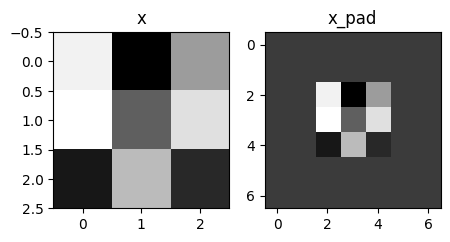

In [3]:
np.random.seed(1)
x = np.random.randn(4, 3, 3, 2)
x_pad = zero_pad(x, 2)
print ("x.shape =", x.shape)
print ("x_pad.shape =", x_pad.shape)
print ("x[1,1] =", x[1,1])
print ("x_pad[1,1] =", x_pad[1,1])

fig, axarr = plt.subplots(1, 2)
axarr[0].set_title('x')
axarr[0].imshow(x[0,:,:,0])
axarr[1].set_title('x_pad')
axarr[1].imshow(x_pad[0,:,:,0])

**Résultat attendu**:

<table>
    <tr>
        <td>
            x.shape:
        </td>
        <td>
           (4, 3, 3, 2)
        </td>
    </tr>
        <tr>
        <td>
            x_pad.shape:
        </td>
        <td>
           (4, 7, 7, 2)
        </td>
    </tr>
        <tr>
        <td>
            x[1,1]:
        </td>
        <td>
            [[ 0.90085595 -0.68372786]
             [-0.12289023 -0.93576943]
             [-0.26788808  0.53035547]]
        </td>
    </tr>
        <tr>
        <td>
            x_pad[1,1]:
        </td>
        <td>
            [[ 0.  0.]
             [ 0.  0.]
             [ 0.  0.]
             [ 0.  0.]
             [ 0.  0.]
             [ 0.  0.]
             [ 0.  0.]]
        </td>
    </tr>
</table>

<a name='2-2'></a>
### 2.2 - Une seule étape de convolution
Dans cette partie, implémentez une seule étape de convolution, dans laquelle vous appliquez le filtre à une seule position de l'entrée. Ceci sera utilisé pour construire une unité convolutive, qui :

- Prend un volume d'entrée
- Applique un filtre à chaque position de l'entrée
- Émet un autre volume (généralement de taille différente)

<img src="images/Convolution_schematic.gif" style="width:400px;height:250px;">

Dans une application de vision par ordinateur, chaque valeur de la matrice de gauche correspond à une seule valeur de pixel, et nous convoluons un filtre 3x3 avec l'image en multipliant ses valeurs élément par élément avec la matrice d'origine, puis en les additionnant et en ajoutant un biais. Dans cette première étape de l'exercice, vous implémenterez une seule étape de convolution, correspondant à l'application d'un filtre à une seule des positions pour obtenir une seule sortie à valeur réelle.

Ensuite, vous appliquerez cette fonction à plusieurs positions de l’entrée pour implémenter l’opération convolutive complète.

<a name='ex-2'></a>
### Exercice 2 - conv_single_step
Implémentez conv_single_step(). [Indice](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.sum.html).

In [4]:
## conv_single_step

def conv_single_step(h_slice_prev, V, b):
    """
    Appliquez un filtre défini par les paramètres V sur une seule tranche 
    (h_slice_prev) de l'activation de sortie de la couche précédente.
    
    Paramètres :
    h_slice_prev -- tranche de données d'entrée de forme (f, f, d_C_prev)
    V -- Paramètres de poids contenus dans une fenêtre - matrice de forme (f, f, d_C_prev)
    b -- Paramètres de biais contenus dans une fenêtre - matrice de forme (1, 1, 1)
    
    Retour :
    Z -- une valeur scalaire, résultat de la convolution de la fenêtre glissante (V, b) 
        sur une tranche x des données d'entrée
    """

    ## Produit par élément entre h_slice_prev et V. N'ajoutez pas encore le biais.
    # s = ...
    ########## 1 ligne ##########
    s = np.multiply(h_slice_prev, V)
    #############################
    
    ## Somme sur toutes les entrées du volume s.
    # Z = ...
    ########## 1 ligne ##########
    Z = np.sum(s)
    #############################
    
    ## Ajoutez le biais b à Z. Convertissez b en float() pour que Z donne une valeur scalaire.
    # Z = ...
    ########## 1 ligne ##########
    Z = Z + float(b)
    #############################

    return Z

In [5]:
np.random.seed(1)
h_slice_prev = np.random.randn(4, 4, 3)
V = np.random.randn(4, 4, 3)
b = np.random.randn(1, 1, 1)

Z = conv_single_step(h_slice_prev, V, b)
print("Z =", Z)

Z = -6.999089450680221


**Résultat attendu**:
<table>
    <tr>
        <td>
            Z
        </td>
        <td>
            -6.99908945068
        </td>
    </tr>
</table>

<a name='2-3'></a>
### 2.3 - Propagation avant
Lors du propagation avant, vous prendrez de nombreux filtres et les appliquerez à l'entrée par convolution. Chaque « convolution » vous donne une sortie sous forme de matrice 2D. Vous empilerez ensuite ces sorties pour obtenir un volume 3D.
<img src="images/convolution-with-multiple-filters.png" style="width:500px;height:250px;">



<a name='ex-3'></a>
### Exercice 3 - conv_forward
Implémentez la fonction ci-dessous pour convoluer les filtres sur une activation d'entrée H_prev. Cette fonction prend comme entrée H_prev, les activations sorties par la couche précédente (pour un lot de $n$ entrées), les filtres/poids notés $V$ et un vecteur de biais noté $b$, où chaque filtre a son propre (unique) biais. Enfin, vous avez également accès au dictionnaire des hyperparamètres qui contient la foulée et le padding.

**Indice**:
1. Pour sélectionner une tranche 2x2 dans le coin supérieur gauche d'une matrice "h_prev" (de forme (5,5,3)), vous feriez :
```python
h_slice_prev = h_prev[0:2,0:2,:]
```
Cela sera utile lorsque vous définirez `h_slice_prev` ci-dessous, en utilisant les indices start/end que vous définirez.
2. Pour définir a_slice, vous devrez d'abord définir ses coins `vert_start`, `vert_end`, `horiz_start` et `horiz_end`. Cette figure peut vous être utile pour découvrir comment chacun des coins peut être défini en utilisant $h$ (hauteur), $l$ (largeur), $f$ (forme de noyau) et $s$ (stride) dans le code ci-dessous.

<img src="images/vert_horiz_kiank.png" style="width:400px;height:300px;">

**Rappel** :
Les formules reliant la forme de sortie de la convolution à la forme d'entrée sont :
$$ d_H = \lfloor \frac{d_{H_{prev}} - f + 2 \times pad + stride}{stride} \rfloor$$
$$ d_L = \lfloor \frac{d_{L_{prev}} - f + 2 \times pad + stride}{(pas) stride} \rfloor$$
$$ d_C = \text{nombre de filtres utilisés dans la convolution}$$

Pour cet exercice, nous ne nous soucierons pas de la vectorisation et nous implémenterons simplement le tout avec des boucles for.

In [6]:
## conv_forward

def conv_forward(H_prev, V, b, hparameters):
    """
    Implémentez la propagation vers l'avant pour une fonction de convolution
    
    Paramètres :
    A_prev -- activations de sortie de la couche précédente, tableau numpy de forme (n, d_H_prev, d_L_prev, d_C_prev)
    V -- Poids, tableau numpy de forme (f, f, d_C_prev, d_C)
    b -- Biais, tableau numpy de forme (1, 1, 1, d_C)
    hparameters -- dictionnaire python contenant `stride` et `pad`
        
    Retour :
    Z -- sortie de `conv`, tableau numpy de forme (n, d_H, d_W, d_C)
    cache -- cache des valeurs nécessaires à la fonction `conv_backward()`
    """
    
    ## Récupérez les dimensions de la forme de H_prev  
    ########## 1 ligne ##########
    (n, d_H_prev, d_L_prev, d_C_prev) = H_prev.shape
    #############################
    
    ## Récupérez les dimensions de la forme du V
    ########## 1 ligne ##########
    (f, f, d_C_prev, d_C) = V.shape
    #############################
    
    ## Récupérez les informations de "hparameters"
    # stride = ...
    # pad = ...
    ######### 2 lignes ##########
    stride = hparameters['stride']
    pad = hparameters['pad']
    #############################
    
    ## Calculez les dimensions du volume de sortie CONV en utilisant la formule donnée ci-dessus.
    ## Indice : utilisez `int()` pour plancher.
    # d_H = ...
    # d_L = ...
    ######### 2 lignes ##########
    d_H = int((d_H_prev - f + 2 * pad + stride) / stride)
    d_L = int((d_L_prev - f + 2 * pad + stride) / stride)
    #############################
    
    ## Initialisez le volume de sortie Z avec des zéros.
    # Z = ...
    ########## 1 ligne ##########
    Z = np.zeros((n, d_H, d_L, d_C))
    #############################
    
    ## Créez H_prev_pad en remplissant H_prev
    H_prev_pad = zero_pad(H_prev, pad)
    
    for i in range(n):                                 # Bouclez le lot d'exemples d'entraînement
        h_prev_pad = H_prev_pad[i]                     # Sélectionnez l'activation rembourrée de l'exemple d'entraînement
        for h in range(d_H):                           # Bouclez sur l'axe vertical du volume de sortie
            for l in range(d_L):                       # Bouclez sur l'axe horizontal du volume de sortie
                for c in range(d_C):                   # Bouclez sur les canaux (= #filters) du volume de sortie
                    
                    ## Trouvez les coins de la "tranche(slice)" actuelle
                    # vert_start = ...
                    # vert_end = ...
                    # horiz_start = ...
                    # horiz_end = ...
                    ######### 4 lignes ##########
                    vert_start = h * stride
                    vert_end = vert_start + f
                    horiz_start = l * stride
                    horiz_end = horiz_start + f
                    #############################
                    
                    ## Utilisez les coins pour définir la tranche (3D) de h_prev_pad
                    # h_slice_prev = ...
                    ########## 1 ligne ##########
                    h_slice_prev = h_prev_pad[vert_start:vert_end, horiz_start:horiz_end, :]
                    #############################
                    
                    ## Convoluez la tranche (3D) avec le filtre V et le biais b corrects, pour récupérer un neurone de sortie.
                    # Z[i, h, l, c] = ...
                    ########## 1 ligne ##########
                    Z[i, h, l, c] = conv_single_step(h_slice_prev, V[...,c], b[...,c])
                    #############################
    
    ## Vous assurez que la forme de votre sortie est correcte
    assert(Z.shape == (n, d_H, d_L, d_C))
    
    ## Enregistrez les informations dans le "cache" pour la backpropagation
    # cache = ...
    ########## 1 ligne ##########
    cache = (H_prev, V, b, hparameters)
    #############################
    
    return Z, cache

In [7]:
np.random.seed(1)
H_prev = np.random.randn(10,4,4,3)
V = np.random.randn(2,2,3,8)
b = np.random.randn(1,1,1,8)
hparameters = {"pad" : 2,
               "stride": 2}

Z, cache_conv = conv_forward(H_prev, V, b, hparameters)
print("moyen de Z =", np.mean(Z))
print("Z[3,2,1] =", Z[3,2,1])
print("cache_conv[0][1][2][3] =", cache_conv[0][1][2][3])

moyen de Z = 0.048995203528855794
Z[3,2,1] = [-0.61490741 -6.7439236  -2.55153897  1.75698377  3.56208902  0.53036437
  5.18531798  8.75898442]
cache_conv[0][1][2][3] = [-0.20075807  0.18656139  0.41005165]


**Résultat attendu**:

<table>
    <tr>
        <td>
            moyen de Z
        </td>
        <td>
            0.0489952035289
        </td>
    </tr>
    <tr>
        <td>
            Z[3,2,1]
        </td>
        <td>
            [-0.61490741 -6.7439236  -2.55153897  1.75698377  3.56208902  0.53036437
              5.18531798  8.75898442]
        </td>
    </tr>
    <tr>
        <td>
            cache_conv[0][1][2][3]
        </td>
        <td>
            [-0.20075807  0.18656139  0.41005165]
        </td>
    </tr>
</table>

Enfin, la couche CONV doit également contenir une activation, auquel cas nous ajouterions la ligne de code suivante :
```python
## Convolution de la fenêtre pour récupérer un neurone de sortie
Z[i, h, l, c] = ...
## Appliquer l'activation
H[i, h, l, c] = activation(Z[i, h, l, c])
```

Vous n'avez pas besoin de le faire ici.

<a name='3'></a>
## 3 - Couche de pooling
La couche de pooling (POOL) réduit la hauteur et la largeur de l'entrée. Cela permet de réduire les calculs et de rendre les détecteurs de caractéristiques plus invariants par rapport à leur position dans l'entrée. Les deux types de couches de pooling sont :

- Couche de pooling maximum : fait glisser une fenêtre ($f, f$) sur l'entrée et stocke la valeur maximale de la fenêtre dans la sortie.

- Couche de pooling moyen : fait glisser une fenêtre ($f, f$) sur l'entrée et stocke la valeur moyenne de la fenêtre dans la sortie.

<img src="images/pooling_pas2.png" style="width:500px;height:250px;">

Ces couches de pooling n'ont aucun paramètre de rétropropagation à entraîner. Cependant, ils ont des hyperparamètres tels que la taille de la fenêtre $f$. Ceci spécifie la hauteur et la largeur de la fenêtre fxf sur laquelle vous calculeriez un maximum ou une moyenne.

<a name='3.1'></a>
### 3.1 - Propagation du Pooling
Maintenant, vous allez implémenter MAX-POOL et AVG-POOL, dans la même fonction.

<a name='ex-4'></a>
### Exercice 4 - pool_forward
Implémentez le passage direct de la couche de pooling. Suivez les conseils dans les commentaires ci-dessous.

**Rappel** :
Comme il n'y a pas de remplissage, les formules liant la forme de sortie du pooling à la forme d'entrée sont :
$$ d_H = \lfloor \frac{d_{H_{prev}} - f}{stride} \rfloor +1 $$
$$ d_L = \lfloor \frac{d_{L_{prev}} - f}{stride} \rfloor +1 $$
$$ d_C = d_{C_{précédent}}$$

In [8]:
## pool_forward

def pool_forward(H_prev, hparameters, mode = "max"):
    """
    Implémente la propagation avant de la couche de pooling
    
    Paramètres :
    H_prev -- Données d'entrée, tableau numpy de forme (n, d_H_prev, d_L_prev, d_C_prev)
    hparameters -- dictionnaire python contenant "f" et "stride"
    mode -- le mode de pooling que vous souhaitez utiliser, défini sous forme de chaîne ("max" ou "moyenne")
    
    Retour :
    H -- sortie de la couche pool, un tableau numpy de forme (n, d_H, d_L, d_C)
    cache -- le cache utilisé dans la rétropropagation de la couche de pooling, contient l'entrée et les paramètres (hparameters)
    """
    
    ## Récupérez les dimensions de la forme d'entrée
    ########## 1 ligne ##########
    (n, d_H_prev, d_L_prev, d_C_prev) = H_prev.shape
    #############################
    
    ## Récupérez les hyperparamètres de "hparameters"
    # f = ...
    # stride = ...
    ######### 2 lignes ##########
    f = hparameters["f"]
    stride = hparameters["stride"]
    #############################
    
    ## Définissez les dimensions de la sortie
    # d_H = int(...)
    # d_L = int(...)
    # d_C = ...
    ######### 3 lignes ##########
    d_H = int(1 + (d_H_prev - f) / stride)
    d_L = int(1 + (d_L_prev - f) / stride)
    d_C = d_C_prev
    #############################
    
    ## Initialisez la matrice de sortie H
    # H = ...
    ########## 1 ligne ##########
    H = np.zeros((n, d_H, d_L, d_C))
    #############################
    
    for i in range(n):                           # bouclez sur les exemples de formation
        for h in range(d_H):                     # bouclez sur l'axe vertical du volume de sortie
            for l in range(d_L):                 # bouclez sur l'axe horizontal du volume de sortie
                for c in range (d_C):            # bouclez sur les canaux du volume de sortie
                    
                    ## Trouver les coins de la "tranche" actuelle
                    # vert_start = ...
                    # vert_end = ...
                    # horiz_start = ...
                    # horiz_end = ...
                    ######### 4 lignes ##########
                    vert_start = h * stride
                    vert_end = vert_start + f
                    horiz_start = l * stride
                    horiz_end = horiz_start + f
                    #############################
                    
                    ## Utilisez les coins pour définir la tranche actuelle sur le ième exemple d'entraînement de H_prev
                    ## canal c
                    # h_prev_slice = ...
                    ########## 1 ligne ##########
                    h_prev_slice = H_prev[i, vert_start:vert_end, horiz_start:horiz_end, c]
                    #############################
                    
                    ## Calculez l’opération de pooling sur la tranche
                    ## Utilisez "np.max" ou "np.mean"
                    # H[i, h, l, c] = ...
                    if mode == "max":
                        ########## 1 ligne ##########
                        H[i, h, l, c] = np.max(h_prev_slice)
                        #############################
                    elif mode == "average":
                        ########## 1 ligne ##########
                        H[i, h, l, c] = np.mean(h_prev_slice)
                        #############################
    
    
    ## Stockez l'entrée et les paramètres dans le "cache" pour pool_backward()
    cache = (H_prev, hparameters)
    
    ## Vous assurez que la forme de votre sortie est correcte
    assert(H.shape == (n, d_H, d_L, d_C))
    
    return H, cache

In [9]:
np.random.seed(1)
H_prev = np.random.randn(2, 4, 4, 3)
hparameters = {"stride" : 2, "f": 3}

H, cache = pool_forward(H_prev, hparameters)
print("mode = max")
print("H =", H)
print()
H, cache = pool_forward(H_prev, hparameters, mode = "average")
print("mode = average")
print("H =", H)

mode = max
H = [[[[1.74481176 0.86540763 1.13376944]]]


 [[[1.13162939 1.51981682 2.18557541]]]]

mode = average
H = [[[[ 0.02105773 -0.20328806 -0.40389855]]]


 [[[-0.22154621  0.51716526  0.48155844]]]]


**Résultat attendu** :
<table>
    <tr>
    <td>
    H  =
    </td>
        <td>
         [[[[ 1.74481176  0.86540763  1.13376944]]]
          [[[ 1.13162939  1.51981682  2.18557541]]]]
        </td>
    </tr>
    <tr>
    <td>
    H  =
    </td>
        <td>
         [[[[ 0.02105773 -0.20328806 -0.40389855]]]
          [[[-0.22154621  0.51716526  0.48155844]]]]
        </td>
    </tr>
</table>

========================================================================================
========================================================================================
<a name='4'></a>
## 4 - Rétropropagation dans les CNNs
Dans les frameworks d'apprentissage profond modernes, il suffit généralement d'implémenter la propagation avant, et le framework se charge de la rétropropagation, de sorte que la plupart des ingénieurs en apprentissage profond n'ont pas besoin de se soucier des détails de la rétropropagation. La rétropropagation pour les réseaux convolutifs est toutefois complexe. Si vous le souhaitez cependant, vous pouvez parcourir cette partie facultative du bloc-notes pour avoir une idée de la façon dont se déroule la rétropropagation dans un réseau convolutionnel.

Lorsque, dans un cours précédent, vous avez implémenté un réseau neuronal simple (entièrement connecté), vous avez utilisé la rétropropagation pour calculer les dérivées par rapport au coût afin de mettre à jour les paramètres. De même, dans les réseaux de neurones convolutifs, vous pouvez calculer les dérivées par rapport au coût pour mettre à jour les paramètres.

<a name='4.1'></a>
### 4.1 - Rétropropagation dans la couche de convolution
Nous commençons par calculer le gradient de la couche de convolution.

<a name='4.1.1'></a>
#### 4.1.1 - Calculer dH
Voici la formule pour calculer $dH$ par rapport au coût d'un certain filtre $V_c$ pour un exemple de formation donné :

$$dH += \sum _{h=0} ^{d_H} \sum_{l=0} ^{d_L} V_c \times dZ_{h,l}$$

Où $V_c$ est un filtre et $dZ_{h,l}$ est un scalaire correspondant au gradient du coût par rapport à la sortie de la couche de convolution $Z$ à la h-ième ligne et la l-ième colonne (correspondant au produit scalaire pris à la i-ième position horizontale et à la j-ième position verticale). Remarquez qu'à chaque itération, nous multiplions le même filtre $V_c$ par un $dZ$ différent lors de la mise à jour de $dH$. Nous le faisons principalement parce que lors du calcul de la propagation avant, chaque filtre est appliqué à différentes tranches de l'entrée, résumées par différentes valeurs de h_slice. Par conséquent, lors du calcul de la rétropropagation pour $dH$, nous ajoutons simplement les gradients de toutes les h_slices.

Dans le code, à l'intérieur des boucles for appropriées, cette formule se traduit par :
```python
dh_prev_pad[vert_start:vert_end, horiz_start:horiz_end, :] += V[:,:,:,c] * dZ[i, h, l, c]
```

<a name='4.1.2'></a>
#### 4.1.2 - Calculer dV
Voici la formule pour calculer $dV_c$ (où $dV_c$ est la dérivée d'un filtre) par rapport à la perte :

$$dV_c += \sum _{h=0} ^{d_H} \sum_{l=0} ^ {d_L} h_{slice} \times dZ_{h,l}$$

Où $h_{slice}$ correspond à la tranche qui a été utilisée pour générer l'activation $Z_{i,j}$. Par conséquent, cela nous donne le gradient de $V$ par rapport à cette tranche, puisque c'est le même $V$. Nous additionnons simplement tous ces gradients pour obtenir $dV$.

Dans le code, à l'intérieur des boucles for appropriées, cette formule se traduit par :
```python
dV[:,:,:,c] += h_slice * dZ[i, h, l, c]
```

<a name='4.1.3'></a>
#### 4.1.3 - Calculer db
Voici la formule pour calculer $db$ par rapport au coût d'un certain filtre $V_c$ :

$$db = \sum_h \sum_l dZ_{h,l}$$

Comme vous l'avez déjà vu dans les réseaux neuronaux de base, $db$ est calculé en additionnant $dZ$. Dans ce cas, vous additionnez simplement tous les gradients de la sortie de la convolution ($Z$) par rapport au coût.

Dans le code, à l'intérieur des boucles for appropriées, cette formule se traduit par :
```python
db[:,:,:,c] += dZ[i, h, l, c]
```

<a name='ex-5'></a>
#### Exercice 5 - conv_backward
Implémentez la fonction `conv_backward` ci-dessous. Vous devez additionner tous les exemples d'entraînement, filtres, hauteurs et largeurs. Vous devez ensuite calculer les dérivées en utilisant les formules ci-dessus.

In [10]:
def conv_backward(dZ, cache):
    """
    Implémentez la rétropropagation pour une fonction de convolution
    
    Paramètres :
    dZ -- gradient du coût par rapport à la sortie de la couche de conversion (Z),
          tableau numpy de forme (n, d_H, d_L, d_C)
    cache -- cache des valeurs nécessaires au conv_backward(), sortie de conv_forward()
    
    Retour :
    dH_prev -- gradient du coût par rapport à l'entrée de la couche de conv (H_prev),
               tableau numpy de forme (n, d_H_prev, d_L_prev, d_C_prev)
    dV -- gradient du coût par rapport aux poids de la couche de conversion (V)
          tableau numpy de forme (f, f, d_C_prev, d_C)
    db -- gradient du coût par rapport aux biais de la couche conv (b)
          tableau numpy de forme (1, 1, 1, d_C)
    """
    
    ## Récupérez des informations du "cache"
    ########## 1 ligne ##########
    (H_prev, V, b, hparameters) = cache
    #############################
    
    ## Récupérez les dimensions de la forme de H_prev
    ########## 1 ligne ##########
    (n, d_H_prev, d_L_prev, d_C_prev) = H_prev.shape
    #############################
    
    ## Récupérez les dimensions de la forme du V
    ########## 1 ligne ##########
    (f, f, d_C_prev, d_C) = V.shape
    #############################
    
    ## Récupérez les informations de "hparameters"
    # stride = ...
    # pad = ...
    ######### 2 lignes ##########
    stride = hparameters["stride"]
    pad = hparameters["pad"]
    #############################
    
    ## Récupérez les dimensions de la forme de dZ
    ########## 1 ligne ##########
    (n, d_H, d_L, d_C) = dZ.shape
    #############################
    
    ## Initialisez dH_prev, dV, db avec les formes correctes
    # dH_prev = ...                           
    # dV = ...
    # db = ...
    ######### 3 lignes ##########
    dH_prev = np.zeros((n, d_H_prev, d_L_prev, d_C_prev))                           
    dV = np.zeros((f, f, d_C_prev, d_C))
    db = np.zeros((1, 1, 1, d_C))
    #############################

    ## Pad H_prev et dH_prev
    # H_prev_pad = ...
    # dH_prev_pad = ...
    ######### 2 lignes ##########
    H_prev_pad = zero_pad(H_prev, pad)
    dH_prev_pad = zero_pad(dH_prev, pad)
    #############################
    
    for i in range(n):                         ## bouclez sur les exemples de formation
        
        ## sélectionnez le i-ème exemple de formation dans H_prev_pad et dH_prev_pad
        # h_prev_pad = ...
        # dh_prev_pad = ...
        ######### 2 lignes ##########
        h_prev_pad = H_prev_pad[i]
        dh_prev_pad = dH_prev_pad[i]
        #############################
        
        for h in range(d_H):                   ## bouclez sur l'axe vertical du volume de sortie
            for l in range(d_L):               ## bouclez sur l'axe horizontal du volume de sortie
                for c in range(d_C):           ## bouclez sur les canaux du volume de sortie
                    
                    ## Trouvez les coins de la "(slice)tranche" actuelle
                    # vert_start = ...
                    # vert_end = ...
                    # horiz_start = ...
                    # horiz_end = ...
                    ######### 4 lignes ##########
                    vert_start = h
                    vert_end = vert_start + f
                    horiz_start = l
                    horiz_end = horiz_start + f
                    #############################
                    
                    ## Utilisez les coins pour définir la tranche depuis h_prev_pad
                    # h_slice = ...
                    ########## 1 ligne ##########
                    h_slice = h_prev_pad[vert_start:vert_end, horiz_start:horiz_end, :]
                    #############################

                    ## Mettez à jour les dégradés de la fenêtre et les paramètres du filtre à l'aide des formules de code données ci-dessus
                    # dh_prev_pad[vert_start:vert_end, horiz_start:horiz_end, :] += ...
                    # dV[:,:,:,c] += ...
                    # db[:,:,:,c] += ...
                    ######### 3 lignes ##########
                    dh_prev_pad[vert_start:vert_end, horiz_start:horiz_end, :] += V[:,:,:,c] * dZ[i, h, l, c]
                    dV[:,:,:,c] += h_slice * dZ[i, h, l, c]
                    db[:,:,:,c] += dZ[i, h, l, c]
                    #############################
                    
        ## Définissez le dH_prev du ième exemple de formation sur le dh_prev_pad non complété 
        ## （Indice : utilisez X[pad:-pad, pad:-pad, :])
        # dH_prev[i, :, :, :] = ...
        ########## 1 ligne ##########
        dH_prev[i, :, :, :] = dh_prev_pad[pad:-pad, pad:-pad, :]
        #############################
    
    ## Vous assurez que la forme de votre sortie est correcte
    assert(dH_prev.shape == (n, d_H_prev, d_L_prev, d_C_prev))
    
    return dH_prev, dV, db

In [11]:
np.random.seed(1)
dH, dV, db = conv_backward(Z, cache_conv)
print("dH_mean =", np.mean(dH))
print("dV_mean =", np.mean(dV))
print("db_mean =", np.mean(db))

dH_mean = 0.6347704472654743
dV_mean = 1.5572657428497354
db_mean = 7.839232564616838


**Résultat attendu** :
<table>
    <tr>
        <td>
            dH_mean
        </td>
        <td>
            0.6347704472654743
        </td>
    </tr>
    <tr>
        <td>
            dV_mean
        </td>
        <td>
            1.5572657428497354
        </td>
    </tr>
    <tr>
        <td>
            db_mean
        </td>
        <td>
            7.839232564616838
        </td>
    </tr>
</table>

<a name='4.2'></a>
### 4.2 - Rétropropagation dans la couche de pooling
Nous calculons ensuite le gradient de la couche de pooling, en commençant par la couche MAX-POOL. Même si une couche de pooling ne dispose d'aucun paramètre de rétropropagation à mettre à jour, vous devez toujours rétropropager le gradient à travers la couche de pooling pour calculer les gradients des couches antérieures à la couche de pooling.

<a name='4.2.1'></a>
#### 4.2.1 - Max pooling
Avant de vous lancer dans la rétropropagation de la couche de pooling, vous allez créer une fonction d'assistance appelée create_mask_from_window() qui fait ce qui suit :
$$ X = \begin{bmatrix}
1 && 3 \\
4 && 2
\end{bmatrix} \quad \rightarrow \quad M =\begin{bmatrix}
0 && 0 \\
1 && 0
\end{bmatrix}$$

Comme vous pouvez le voir, cette fonction crée une matrice "masque" qui garde la trace de l'endroit où se trouve le maximum dans $X$. `True` (1) indique la position du maximum dans $X$, les autres entrées sont `False` (0). Vous verrez plus tard que la passe arrière pour le pooling moyen sera similaire à celle-ci mais en utilisant un masque différent.

<a name='ex-6'></a>
#### Exercice 6 - create_mask_from_window
Implémentez `create_mask_from_window()`. Cette fonction sera utile pour le pooling vers l’arrière.

Indices :
- [np.max()](https://numpy.org/doc/stable/reference/generated/numpy.max.html) peut être utile. Il calcule le maximum d'un tableau.
- Si vous avez une matrice X et un scalaire x : `H = (X == x)` renverra une matrice H de la même taille que X telle que :
```
H[i,j] = True if X[i,j] = x
H[i,j] = False if X[i,j] != x
```
- Ici, vous n'avez pas besoin de considérer les cas où il y a plusieurs maxima dans une matrice.

In [12]:
def create_mask_from_window(x):
    """
    Créez un masque à partir d'une matrice d'entrée x, pour identifier l'entrée maximale de x.
    
    Paramètres :
    x -- Tableau de forme (f, f)
    
    Retour :
    mask -- Tableau de même forme que window, contient un True à la position correspondant à l'entrée maximale de x.
    """
    
    # mask = ...
    ########## 1 ligne ##########
    mask = x == np.max(x)
    #############################
    
    return mask

In [13]:
np.random.seed(1)
x = np.random.randn(2,3)
mask = create_mask_from_window(x)
print('x = ', x)
print("mask = ", mask)

x =  [[ 1.62434536 -0.61175641 -0.52817175]
 [-1.07296862  0.86540763 -2.3015387 ]]
mask =  [[ True False False]
 [False False False]]


**Résultat attendu** : 

<table> 
    <tr> 
        <td>
        x =
        </td>
        <td>
        [[ 1.62434536 -0.61175641 -0.52817175] <br>
         [-1.07296862  0.86540763 -2.3015387 ]]
        </td>
    </tr>
    <tr> 
        <td>
        mask =
        </td>
        <td>
        [[ True False False] <br>
         [False False False]]
        </td>
    </tr>
</table>

Pourquoi devons-nous suivre l’emplacement du maximum ? Parce que la valeur maximale est l'élément d'entrée qui influe sur la sortie finale, ou c'est la variable de la fonction de coût. Lors de la rétropropagation, nous calculons le gradient par rapport au coût, donc tout facteur qui influe sur le coût final doit avoir un gradient non nul.

<a name='4.2.2'></a>
#### 4.2.2 - Average pooling
Dans le pooling maximum, pour chaque fenêtre d'entrée, toute "l'influence" sur la sortie provient d'une seule valeur d'entrée - le maximum. Dans le pooling moyen, chaque élément de la fenêtre d'entrée a une influence égale sur la sortie. Donc, pour implémenter la rétropropagation, vous allez maintenant créer une fonction d'assistance qui reflète cela.

Par exemple, si nous avons effectué un pooling moyen lors de la passe avant en utilisant un filtre 2x2, le masque que vous utiliserez pour la rétropropagation ressemblera à :
$$ dZ = 1 \quad \rightarrow  \quad dZ =\begin{bmatrix}
1/4 && 1/4 \\
1/4 && 1/4
\end{bmatrix}$$

Cela signifie que chaque position dans la matrice $dZ$ contribue de manière égale à la sortie, car lors de la passe avant, nous avons pris une moyenne.

<a name='ex-7'></a>
#### Exercice 7 - distribute_value
Implémentez la fonction ci-dessous pour distribuer également une valeur dz à travers une matrice de forme de dimension. [Indice](https://numpy.org/doc/stable/reference/generated/numpy.ones.html)

In [14]:
def distribute_value(dz, shape):
    """
    Distribuez la valeur d'entrée dans la matrice de forme de dimension
    
    Paramètres :
    dz -- scalaire d'entrée
    shape -- la forme (d_H, d_L) de la matrice de sortie pour laquelle on veut distribuer la valeur de dz
    
    Retour :
    a -- tableau de taille (d_H, d_L) pour lequel nous avons distribué la valeur de dz
    """
    
    ## Récupérez les dimensions de la forme
    #(d_H, d_L) = ...
    ########## 1 ligne ##########
    (d_H, d_L) = shape
    #############################
    
    ## Calculez la valeur à distribuer sur la matrice
    # average = ...
    ########## 1 ligne ##########
    average = dz / (d_H * d_L)
    #############################
    
    ## Créez une matrice où chaque entrée est la valeur "moyenne"
    # a = ...
    ########## 1 ligne ##########
    a = np.ones(shape) * average
    #############################
    
    return a

In [15]:
a = distribute_value(2, (2,2))
print('valeur distribuée =', a)

valeur distribuée = [[0.5 0.5]
 [0.5 0.5]]


**Résultat attendu** : 

<table> 
    <tr> 
        <td>
        distributed_value =
        </td>
        <td>
        [[ 0.5  0.5]
        <br> 
        [ 0.5  0.5]]
        </td>
    </tr>
</table>

<a name='ex-8'></a>
#### Exercice 8 - pool_backward
Implémentez la fonction `pool_backward` dans les deux modes (`"max"` et `"average"`). Vous utiliserez à nouveau 4 boucles for (en itérant sur les exemples d'entraînement, la hauteur, la largeur et les canaux). Vous devez utiliser une instruction `if/elif` pour vérifier si le mode est égal à `"max"` ou `"average"`. S'il est égal à "average", vous devez utiliser la fonction `distribute_value()` que vous avez implémentée ci-dessus pour créer une matrice de la même forme que `h_slice`. Sinon, si le mode est égal à "max", vous créerez un masque avec `create_mask_from_window()` et le multiplierez par la valeur correspondante de dZ.

In [16]:
def pool_backward(dH, cache, mode = "max"):
    """
    Implémentez la rétropropagation dans la couche de pooling
    
    Paramètres :
    dH -- gradient de coût par rapport à la sortie de la couche de pooling, même forme que H
    cache -- sortie du cache du passage direct de la couche de pooling contient l'entrée et les paramètres de la couche
    mode -- mode de pooling que vous souhaitez utiliser, défini sous forme de chaîne ("max" ou "average")
    
    Retour :
    dH_prev -- gradient de coût par rapport à l'entrée de la couche de pooling, même forme que H_prev
    """
    
    ## Récupérez des informations du cache
    # (H_prev, hparameters) = ...
    ########## 1 ligne ##########
    (H_prev, hparameters) = cache
    #############################
    
    ## Récupérez les hyperparamètres de "hparameters"
    # stride = ...
    # f = ...
    ######### 2 lignes ##########
    stride = hparameters["stride"]
    f = hparameters["f"]
    #############################
    
    ## Récupérez les dimensions de la forme de H_prev et de la forme de dH
    # n, d_H_prev, d_L_prev, d_C_prev = ...
    # n, d_H, d_L, d_C = ...
    ######### 2 lignes ##########
    n, d_H_prev, d_L_prev, d_C_prev = H_prev.shape
    n, d_H, d_L, d_C = dH.shape
    #############################
    
    ## Initialisez dH_prev avec des zéros
    # dH_prev = ...
    ########## 1 ligne ##########
    dH_prev = np.zeros(H_prev.shape)
    #############################
    
    for i in range(n):                         ## bouclez sur les exemples de formation
        ## Sélectionnez un exemple de formation dans A_prev
        h_prev = H_prev[i]
        for h in range(d_H):                   ## bouclez sur l'axe vertical
            for l in range(d_L):               ## bouclez sur l'axe horizontal
                for c in range(d_C):           ## bouclez sur les canaux (profondeur)
                    ## Trouvez les coins de la "tranche(slice)" actuelle
                    # vert_start = ...
                    # vert_end = ...
                    # horiz_start = ...
                    # horiz_end = ...
                    ######### 4 lignes ##########
                    vert_start = h
                    vert_end = vert_start + f
                    horiz_start = l
                    horiz_end = horiz_start + f
                    #############################
                    
                    ## Calculez la rétropropagation dans les deux modes
                    if mode == "max":
                        ## Utilisez les coins et "c" pour définir la tranche actuelle à partir de h_prev
                        # h_prev_slice = ...
                        ########## 1 ligne ##########
                        h_prev_slice = h_prev[vert_start:vert_end, horiz_start:horiz_end, c]
                        #############################
                        ## Créez le masque à partir de h_prev_slice
                        # mask = ...
                        ########## 1 ligne ##########
                        mask = create_mask_from_window(h_prev_slice)
                        #############################
                        ## Définissez dH_prev sur dH_prev + (le masque multiplié par l'entrée correcte de dH)
                        # dH_prev[i, vert_start:vert_end, horiz_start:horiz_end, c] += ...
                        ########## 1 ligne ##########
                        dH_prev[i, vert_start:vert_end, horiz_start:horiz_end, c] += np.multiply(mask, dH[i, h, l, c])
                        #############################
                        
                    elif mode == "average":
                        ## Obtenez la valeur a de dH
                        # dh = ...
                        ########## 1 ligne ##########
                        dh = dH[i, h, l, c]
                        #############################
                        ## Définissez la forme du filtre comme fxf
                        # shape = ...
                        ########## 1 ligne ##########
                        shape = (f, f)
                        #############################
                        ## Distribuez-le pour obtenir la bonne tranche de dH_prev
                        ## Ajouter la valeur distribuée de dh
                        # dH_prev[i, vert_start:vert_end, horiz_start:horiz_end, c] += ...
                        ########## 1 ligne ##########
                        dH_prev[i, vert_start:vert_end, horiz_start:horiz_end, c] += distribute_value(dh, shape)
                        #############################
    
    ## Vous assurez que la forme de votre sortie est correcte
    assert(dH_prev.shape == H_prev.shape)
    
    return dH_prev

In [17]:
np.random.seed(1)
H_prev = np.random.randn(5, 5, 3, 2)
hparameters = {"stride" : 1, "f": 2}
H, cache = pool_forward(H_prev, hparameters)
dH = np.random.randn(5, 4, 2, 2)

dH_prev = pool_backward(dH, cache, mode = "max")
print("mode = max")
print('moyenne de dH = ', np.mean(dH))
print('dH_prev[1,1] = ', dH_prev[1,1])  
print()
dH_prev = pool_backward(dH, cache, mode = "average")
print("mode = average")
print('moyenne de dH = ', np.mean(dH))
print('dH_prev[1,1] = ', dH_prev[1,1]) 

mode = max
moyenne de dH =  0.14571390272918056
dH_prev[1,1] =  [[ 0.          0.        ]
 [ 5.05844394 -1.68282702]
 [ 0.          0.        ]]

mode = average
moyenne de dH =  0.14571390272918056
dH_prev[1,1] =  [[ 0.08485462  0.2787552 ]
 [ 1.26461098 -0.25749373]
 [ 1.17975636 -0.53624893]]


**Résultat attendu**: 

mode = max:
<table> 
    <tr> 
        <td>
        moyenne de dH =
        </td>
        <td>
        0.145713902729
        </td>
    </tr>
    <tr> 
        <td>
        dH_prev[1,1] =
        </td>
        <td>
        [[ 0.          0.        ] <br>
         [ 5.05844394 -1.68282702] <br>
         [ 0.          0.        ]]
        </td>
    </tr>
</table>

mode = average
<table> 
    <tr> 
        <td>
        moyenne de dH =
        </td>
        <td>
        0.145713902729
        </td>
    </tr>
    <tr> 
        <td>
        dH_prev[1,1] =
        </td>
        <td>
        [[ 0.08485462  0.2787552 ] <br>
         [ 1.26461098 -0.25749373] <br>
         [ 1.17975636 -0.53624893]]
        </td>
    </tr>
</table>

========================================================================================
========================================================================================
<a name='5'></a>
## 5 - Implémentation de la reconnaissance d'images (facultatif)
Il s'agit d'une tâche de classification d'images à l'aide d'un réseau de neurones convolutif (CNN), spécifiquement pour déterminer si une image de cerveau contient une tumeur. Le jeu de données est divisé en deux catégories :
- `no` : indiquant qu'il n'y a pas de tumeur dans l'image.
- `yes` : indiquant qu'il y a une tumeur dans l'image.
Le réseau apprend à distinguer ces deux catégories en analysant les caractéristiques des images.



| Fonction                         | État    |
| :------------------------------: | :-----: |
| `zero_pad`                       | ✅ Fait |
| `conv_forward`                   | ✅ Fait |
| `pool_forward`                   | ✅ Fait |
| `conv_backward`                  | ✅ Fait |
| `pool_backward`                  | ✅ Fait |
| `create_mask_from_window`        | ✅ Fait |
| `distribute_value`               | ✅ Fait |
| `initialize_parameters`          | ✖️ Pas fait  |
| `softmax`                        | ✖️ Pas fait  |
| `relu`                           | ✖️ Pas fait  |
| `relu_backward`                  | ✖️ Pas fait  |
| `compute_loss`                   | ✖️ Pas fait  |
| `softmax_cross_entropy_backward` | ✖️ Pas fait  |
| `fully_connected_backward`       | ✖️ Pas fait  |


### Structure du code et guide des opérations
1. Initialisation des paramètres du réseau
- **Fonction** : Initialiser les poids et les biais du réseau.
- **Guide des opérations** :
    - `V1` et `V2` sont les poids des noyaux de convolution, `b1` et `b2` sont les biais des couches de convolution.
    - `W3` et `b3` sont les poids et les biais de la couche entièrement connectée.
    - Les poids sont initialisés avec une petite valeur (multipliée par 0,1) pour éviter l'explosion ou la disparition des gradients.

In [19]:
def initialize_parameters():
    np.random.seed(1)
    
    # Couche de convolution 1 : 1 canal d'entrée, 8 canaux de sortie, noyau de taille 3x3
    V1 = np.random.randn(3, 3, 1, 8) * 0.1
    b1 = np.zeros((1, 1, 1, 8))
    
    # Couche de convolution 2 : 8 canaux d'entrée, 16 canaux de sortie, noyau de taille 3x3
    V2 = np.random.randn(3, 3, 8, 16) * 0.1
    b2 = np.zeros((1, 1, 1, 16))
    
    # Couche entièrement connectée : entrée de taille 16x16x16, sortie de 2 classes (malade / non malade)
    W3 = np.random.randn(16 * 16 * 16, 2) * 0.1
    b3 = np.zeros((1, 2))
    
    return V1, b1, V2, b2, W3, b3

2. Fonctions d'activation et leurs rétropropagations
- **Fonction** :
    - `relu` est une fonction d'activation pour introduire une non-linéarité.
    - `relu_backward` est la rétropropagation de relu, qui calcule les gradients.
    - `softmax` est la fonction d'activation de la couche de sortie pour les problèmes de classification multi-classe.
- **Guide des opérations** :
    - La fonction `relu` remplace toutes les valeurs négatives par 0.
    - Dans `relu_backward`, lorsque Z <= 0, le gradient est 0.
    - La fonction `softmax` normalise les valeurs de sortie en une distribution de probabilité.

In [ ]:
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def relu(Z):
    return np.maximum(0, Z)

def relu_backward(dA, Z):
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

3. Fonction de perte et sa rétropropagation
- **Fonction** :
    - `compute_loss` calcule la perte d'entropie croisée.
    - `softmax_cross_entropy_backward` est la rétropropagation de la perte.
- **Guide des opérations** :
    - La formule de la perte d'entropie croisée est $-\sum y \log(\hat{y})$, où epsilon est utilisé pour éviter de prendre le logarithme de 0.
    - La rétropropagation donne un gradient de $\hat{y}-y$.

In [ ]:
def compute_loss(Y_hat, Y):
    m = Y.shape[0]
    epsilon = 1e-9
    loss = -np.sum(Y * np.log(Y_hat + epsilon)) / m
    return loss

def softmax_cross_entropy_backward(Y_hat, Y):
    return Y_hat - Y  # déjà divisé par m dans la perte

4. Rétropropagation de la couche entièrement connectée
- **Fonction** : Calculer les gradients de la couche entièrement connectée.
- **Guide des opérations** :
    - `dW` est le gradient des poids, `db` est le gradient des biais.
    - `dA_prev` est le gradient transmis à la couche précédente.

In [40]:
def fully_connected_backward(dZ, A_prev):
    m = A_prev.shape[0]
    dW = np.dot(A_prev.T, dZ) / m
    db = np.sum(dZ, axis=0, keepdims=True) / m
    dA_prev = np.dot(dZ, W3.T)  # retourner au niveau précédent
    return dA_prev, dW, db

5. Chargement des données
- **Fonction** : Charger le jeu de données d'images et effectuer des prétraitements.
- **Guide des opérations** :
    - Parcourir les dossiers du jeu de données, lire les images et les convertir en niveaux de gris.
    - Redimensionner les images à une taille fixe (64x64) et normaliser les valeurs des pixels à [0, 1].
    - Stocker les données d'image et les étiquettes respectivement dans X et Y.

In [37]:
import os
import numpy as np
from PIL import Image

def load_brain_dataset(dataset_path, image_size=(64, 64)):
    X = []
    Y = []
    
    for class_name in ["no", "yes"]:
        label = 0 if class_name == "no" else 1
        folder = os.path.join(dataset_path, class_name)
        
        for filename in os.listdir(folder):
            if filename.lower().endswith('.jpg'):
                filepath = os.path.join(folder, filename)
                try:
                    img = Image.open(filepath).convert("L")        # image en niveaux de gris
                    img = img.resize(image_size)                   # redimensionner à une taille fixe
                    img_array = np.array(img) / 255.0              # normalisation
                    X.append(img_array)
                    Y.append(label)
                except Exception as e:
                    print(f"Impossible de traiter l'image {filepath}: {e}")
    
    X = np.array(X).reshape(-1, image_size[0], image_size[1], 1)   # ajouter une dimension de canal
    Y = np.array(Y).reshape(-1, 1)
    return X, Y

6. Processus d'entraînement
- **Fonction** : Effectuer le processus d'entraînement du modèle.
- **Guide des opérations** :
    1. Propagation avant :
        - Première couche de convolution (avec `conv_forward`) et fonction d'activation relu.
        - Couche de max-pooling (avec `pool_forward`).
        - Deuxième couche de convolution et fonction d'activation.
        - Deuxième couche de max-pooling.
        - Aplatir les données pour la couche entièrement connectée.
        - Couche entièrement connectée et fonction d'activation softmax.
    1. Calcul de la perte :
        - Utiliser compute_loss pour calculer la perte d'entropie croisée.
    1. Rétropropagation :
        - Calculer les gradients à partir de la couche de sortie avec softmax_cross_entropy_backward.
        - Propager les gradients à travers la couche entièrement connectée avec fully_connected_backward.
        - Propager les gradients à travers les couches de max-pooling et de convolution.
    1. Mise à jour des paramètres :
        - Mettre à jour les poids et les biais en utilisant le taux d'apprentissage (`lr`).

In [39]:
X, Y = load_brain_dataset("brain_tumor_dataset", image_size=(64, 64))

# Initialisation
V1, b1, V2, b2, W3, b3 = initialize_parameters()
lr = 0.01
epochs = 10

for epoch in range(epochs):
    # Propagation avant
    Z1, cache1 = conv_forward(X, V1, b1, {"pad":1, "stride":1})
    A1 = relu(Z1)
    P1, cache_pool1 = pool_forward(A1, {"stride":2, "f":2})
    
    Z2, cache2 = conv_forward(P1, V2, b2, {"pad":1, "stride":1})
    A2 = relu(Z2)
    P2, cache_pool2 = pool_forward(A2, {"stride":2, "f":2})
    
    F = P2.reshape(P2.shape[0], -1)
    Z3 = np.dot(F, W3) + b3
    Y_hat = softmax(Z3)
    
    # Perte
    loss = compute_loss(Y_hat, Y)
    print(f"Epoch {epoch}, Loss: {loss}")

    # Rétropropagation
    dZ3 = softmax_cross_entropy_backward(Y_hat, Y)
    dF, dW3, db3 = fully_connected_backward(dZ3, F)

    dP2 = dF.reshape(P2.shape)
    dA2 = pool_backward(dP2, cache_pool2, mode='max')
    dZ2 = relu_backward(dA2, Z2)
    dH1, dV2, db2 = conv_backward(dZ2, cache2)

    dA1 = pool_backward(dH1, cache_pool1, mode='max')
    dZ1 = relu_backward(dA1, Z1)
    _, dV1, db1 = conv_backward(dZ1, cache1)

    # Mise à jour des paramètres
    W3 -= lr * dW3
    b3 -= lr * db3
    V2 -= lr * dV2
    b2 -= lr * db2
    V1 -= lr * dV1
    b1 -= lr * db1

Epoch 0, Loss: 0.9051991894766489
Epoch 1, Loss: 11.520937802261765
Epoch 2, Loss: 13.026052811166316
Epoch 3, Loss: 13.026052810503478
Epoch 4, Loss: 13.026052811166316
Epoch 5, Loss: 13.026052811166316
Epoch 6, Loss: 0.8713944884919106
Epoch 7, Loss: 0.8713943940890524
Epoch 8, Loss: 0.871394300627849
Epoch 9, Loss: 0.8713942080989073
